In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../../data/checking-logs.sqlite')

In [3]:
query = """
SELECT 
    uid, datetime
FROM pageviews
WHERE uid LIKE 'user_%'
"""
views = pd.io.sql.read_sql(query, connect, parse_dates=['datetime'])
# Группировка и подсчет просмотров по дням
views = views.groupby(by=views['datetime'].dt.date).count()['uid'].reset_index()
views.columns = ['date', 'views']
views = views.set_index('date')
views

,views
date,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1
2020-04-23,5
2020-04-25,1
2020-04-26,8
2020-04-28,2


In [4]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits = commits.groupby(by=commits['timestamp'].dt.date).count()['uid'].reset_index()
commits.columns = ['date', 'commits']
commits = commits.set_index('date')
commits

,commits
date,
2020-04-17,23
2020-04-18,69
2020-04-19,33
2020-04-20,25
2020-04-21,25
2020-04-22,28
2020-04-23,43
2020-04-24,16
2020-04-25,104


Объединим полученные таблицы

In [5]:
views_commits = pd.concat([views, commits], axis=1)
views_commits = views_commits.dropna()
views_commits

,views,commits
date,,
2020-04-17,1.0,23.0
2020-04-18,23.0,69.0
2020-04-19,15.0,33.0
2020-04-21,3.0,25.0
2020-04-22,1.0,28.0
2020-04-23,5.0,43.0
2020-04-25,1.0,104.0
2020-04-26,8.0,261.0
2020-04-28,2.0,5.0


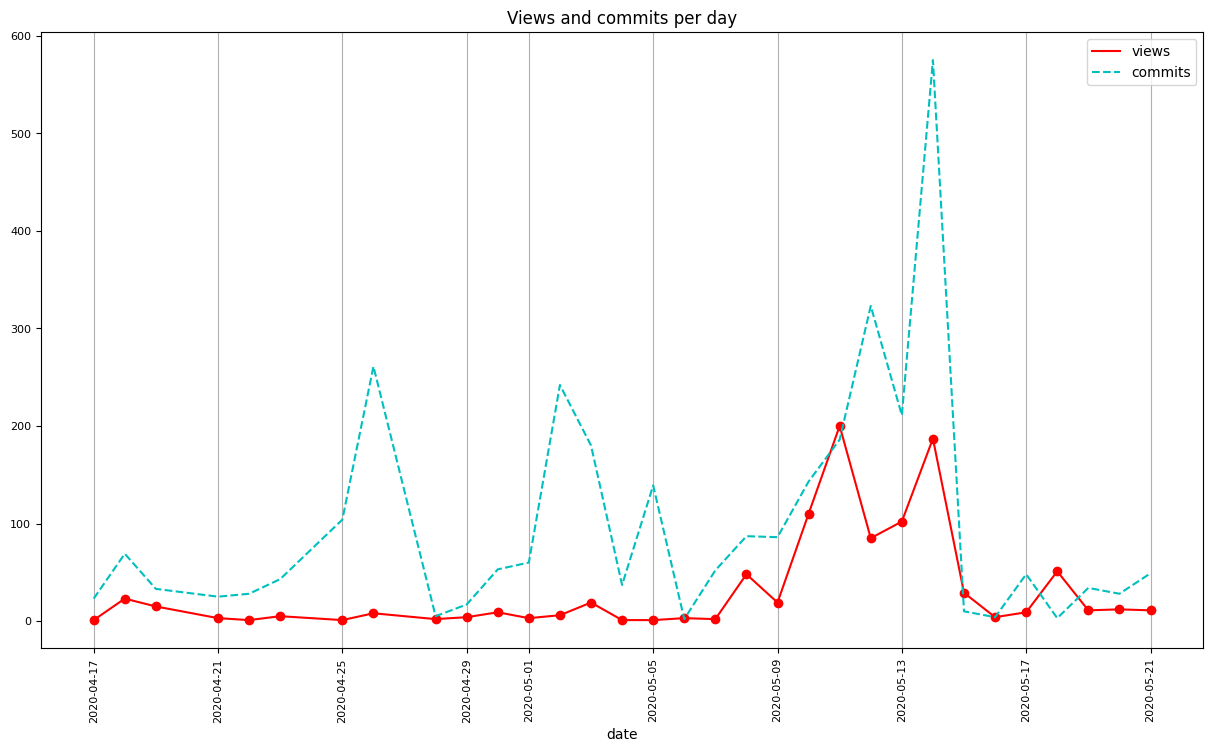

In [6]:
ax = views_commits.plot(fontsize=8,
                        figsize=(15,8),
                        title='Views and commits per day',
                        color=['red', 'c'],
                        style=['-', '--'], 
                        rot=90)
ax.grid(axis = 'x')
ax.get_lines()[0].set_marker('o')

In [7]:
answer = views_commits[views_commits['views'] > 150 ]['views'].count()
answer

np.int64(2)

Ответ 2

In [8]:
connect.close()